# PDD Daily Backtest — full available history (2018-07-26 to 2026-07-10)

This notebook loads `pdd_daily.csv` (PDD's complete daily history since its 2018-07-26 IPO), runs Al-Maghriz with the default parameter set, and plots the close price with stop-loss levels, the open-to-close equity curve (including 2 bps round-trip transaction costs), the executed position, and the drawdown.


In [1]:
import math
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'python'))
from al_maghriz import AlMaghrizModel

%matplotlib inline


In [2]:
csv_path = ROOT / 'examples' / 'pdd_daily.csv'
df = pd.read_csv(csv_path)
# Accept either a 'timestamp' column or the original Yahoo Finance 'Date' column.
time_col = 'timestamp' if 'timestamp' in df.columns else 'Date'
df = df.rename(columns={time_col: 'timestamp'})
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print(f'Loaded {len(df)} rows from {df.timestamp.min()} to {df.timestamp.max()}')
df.head()


Loaded 1999 rows from 2018-07-26 00:00:00+00:00 to 2026-07-10 00:00:00+00:00


,timestamp,open,high,low,close,volume,ticker
0,2018-07-26 00:00:00+00:00,26.500000,27.450001,25.000000,26.700001,43213200,PDD
1,2018-07-27 00:00:00+00:00,27.540001,27.540001,23.209999,24.600000,19923300,PDD
2,2018-07-30 00:00:00+00:00,23.309999,23.900000,21.879999,22.500000,13967700,PDD
3,2018-07-31 00:00:00+00:00,22.200001,22.709999,19.620001,22.590000,13709600,PDD
4,2018-08-01 00:00:00+00:00,19.379999,21.400000,18.620001,20.309999,19339000,PDD


In [3]:
model = AlMaghrizModel(ROOT / 'dist' / 'libal_maghriz.so')
print(model.version())


Al-Maghriz Core 1.0.0


In [4]:
rolling_length = 60
max_hold_bars = 0  # 0 = auto-detect (48 for hourly, 20 for daily)
params = {"A": 2, "B": 4, "C": 0, "D": 1, "E": 0, "F": 0, "G": 2, "H": 2}

positions, stop_losses = model.predict(
    bars=df[["timestamp", "open", "high", "low", "close"]],
    token_path=ROOT / 'certificates' / 'test_20260901.pem',
    user='test',
    password='test',
    rolling_length=rolling_length,
    max_hold_bars=max_hold_bars,
    risk_per_trade=0.05,
    **params,
)

print(f'Target positions: {len(positions)}')
print(f'Stop losses: {len(stop_losses)}')
print(f'Position range: [{min(positions):.4f}, {max(positions):.4f}]')
print(f'Latest target: {positions[-1]:.6f}')
print(f'Latest stop loss: {stop_losses[-1]}')


Target positions: 1940
Stop losses: 1940
Position range: [-1.0000, 1.0000]
Latest target: 0.000000
Latest stop loss: nan


In [5]:
# --- Cost assumptions ---
# 2 bps round-trip transaction cost for equity.
round_trip_cost_bps = 2.0

# --- Align predictions ---
# The engine returns one (position, stop_loss) per bar from index rolling_length-1 onwards.
# It executes at the open of the signal bar and holds through the close.
pred_start = rolling_length - 1
pred_idx = np.arange(pred_start, len(df))
pred_df = pd.DataFrame({
    'timestamp': df['timestamp'].iloc[pred_idx].values,
    'open': df['open'].iloc[pred_idx].values,
    'high': df['high'].iloc[pred_idx].values,
    'low': df['low'].iloc[pred_idx].values,
    'close': df['close'].iloc[pred_idx].values,
    'position': np.asarray(positions, dtype=float),
    'stop_loss': np.asarray(stop_losses, dtype=float),
})

# Open-to-close gross return for the signal bar
gross_ret = pred_df['position'] * (pred_df['close'] / pred_df['open'] - 1.0)

# Transaction cost on position change
trade_size = pred_df['position'].diff().abs()
trade_size.iloc[0] = abs(pred_df['position'].iloc[0])  # entry at first prediction bar
txn_cost = trade_size * round_trip_cost_bps / 10_000
net_ret = gross_ret - txn_cost

pred_df['gross_ret'] = gross_ret
pred_df['net_ret'] = net_ret
pred_df['equity'] = (1.0 + net_ret.fillna(0)).cumprod()
pred_df['drawdown'] = pred_df['equity'] / pred_df['equity'].cummax() - 1.0

print(f'Total return: {pred_df["equity"].iloc[-1] - 1:.2%}')
print(f'Max drawdown: {pred_df["drawdown"].min():.2%}')


Total return: 36.98%
Max drawdown: -14.37%


## Position sizing: `risk_per_trade`

PDD positions are often small because the Chan signals use wide invalidation levels as stops. The target position is sized so that losing the entry-to-stop distance risks `risk_per_trade` of capital (default 0.5%).  Increasing `risk_per_trade` raises exposure on the same signals.

In [6]:
for rpt in [0.005, 0.01, 0.02, 0.05]:
    pos, sl = model.predict(
        bars=df[["timestamp", "open", "high", "low", "close"]],
        token_path=ROOT / 'certificates' / 'test_20260901.pem',
        user='test',
        password='test',
        rolling_length=rolling_length,
        max_hold_bars=max_hold_bars,
        risk_per_trade=rpt,
        **params,
    )
    pos = np.asarray(pos, dtype=float)
    gross = pos * (pred_df['close'].values / pred_df['open'].values - 1.0)
    trade_size = np.abs(np.diff(pos, prepend=0))
    net = gross - trade_size * round_trip_cost_bps / 10_000
    eq = (1.0 + net).cumprod()
    dd = eq / np.maximum.accumulate(eq) - 1.0
    print(f"risk_per_trade={rpt}: pos range=[{pos.min():.3f}, {pos.max():.3f}], "
          f"return={eq[-1]-1:.2%}, max dd={dd.min():.2%}")


risk_per_trade=0.005: pos range=[-0.281, 0.737], return=3.87%, max dd=-1.54%
risk_per_trade=0.01: pos range=[-0.561, 1.000], return=7.71%, max dd=-3.06%


risk_per_trade=0.02: pos range=[-1.000, 1.000], return=14.94%, max dd=-6.06%
risk_per_trade=0.05: pos range=[-1.000, 1.000], return=36.98%, max dd=-14.37%


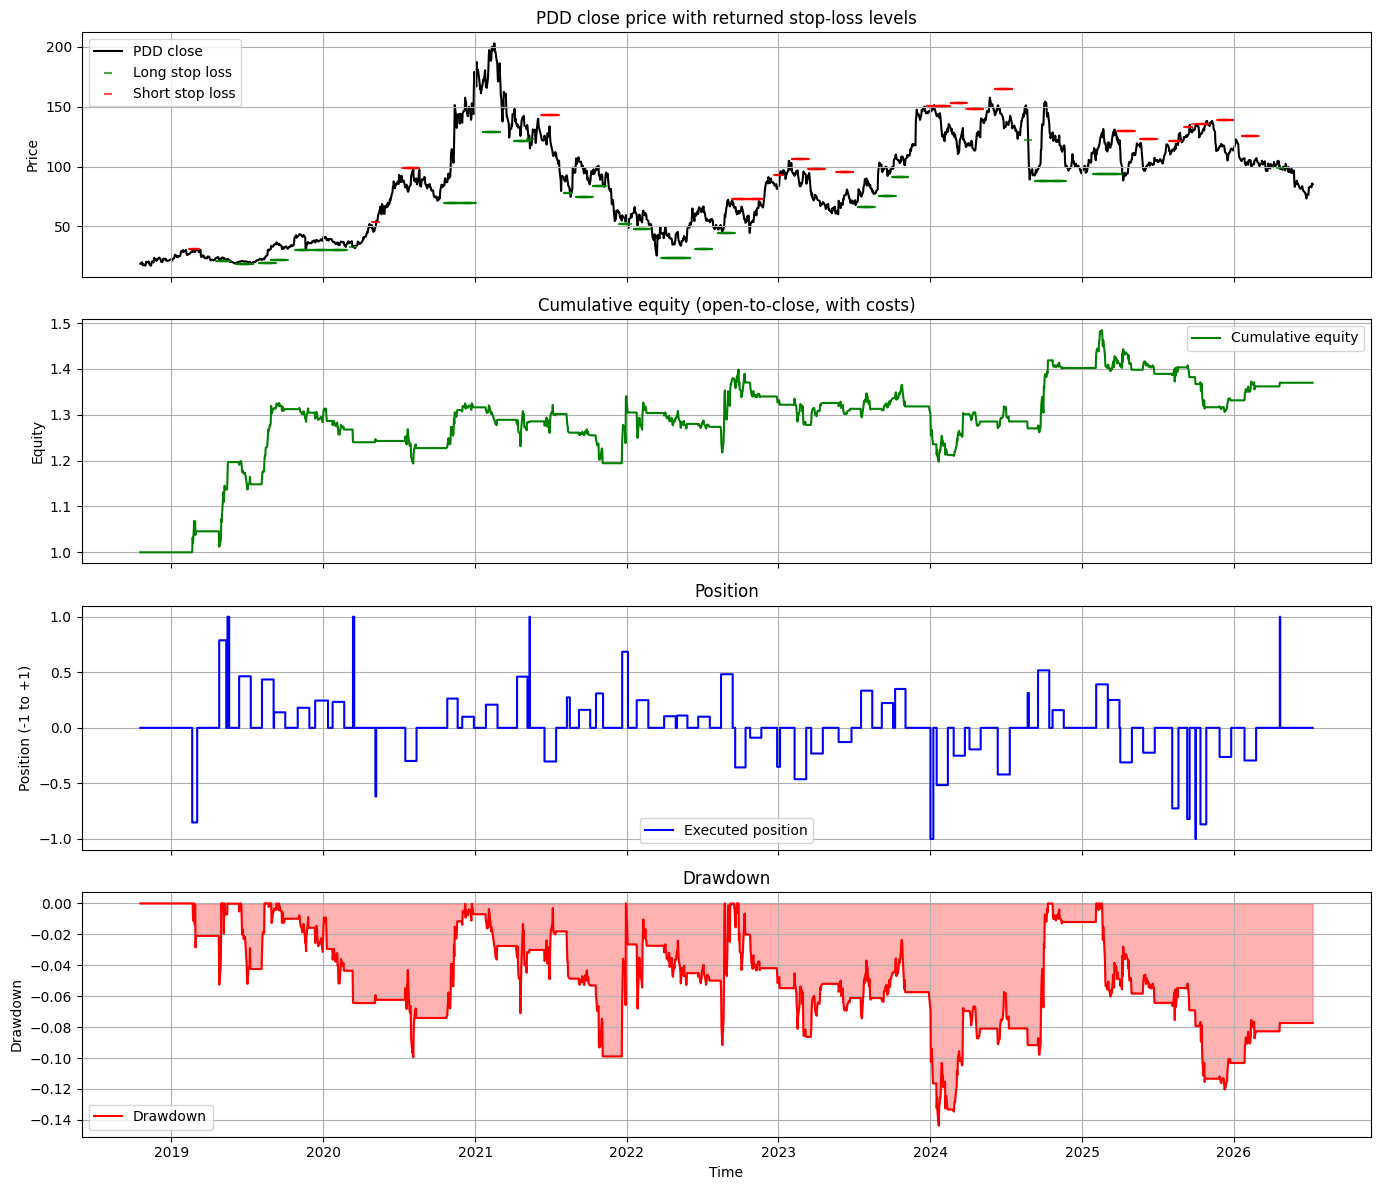

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Price + stop-loss levels
axes[0].plot(pred_df['timestamp'], pred_df['close'], label='PDD close', color='black', zorder=1)
long_mask = pred_df['position'] > 1e-12
short_mask = pred_df['position'] < -1e-12
sl_valid = pred_df['stop_loss'].notna() & (pred_df['stop_loss'] != 0.0) & np.isfinite(pred_df['stop_loss'])
axes[0].scatter(
    pred_df.loc[long_mask & sl_valid, 'timestamp'],
    pred_df.loc[long_mask & sl_valid, 'stop_loss'],
    marker='_', s=40, color='green', alpha=0.7, label='Long stop loss',
    zorder=2,
)
axes[0].scatter(
    pred_df.loc[short_mask & sl_valid, 'timestamp'],
    pred_df.loc[short_mask & sl_valid, 'stop_loss'],
    marker='_', s=40, color='red', alpha=0.7, label='Short stop loss',
    zorder=2,
)
axes[0].set_title('PDD close price with returned stop-loss levels')
axes[0].set_ylabel('Price')
axes[0].legend(loc='upper left')
axes[0].grid(True)

axes[1].plot(pred_df['timestamp'], pred_df['equity'], label='Cumulative equity', color='green')
axes[1].set_title('Cumulative equity (open-to-close, with costs)')
axes[1].set_ylabel('Equity')
axes[1].legend()
axes[1].grid(True)

axes[2].step(pred_df['timestamp'], pred_df['position'], where='post', label='Executed position', color='blue')
axes[2].set_title('Position')
axes[2].set_ylabel('Position (-1 to +1)')
axes[2].legend()
axes[2].grid(True)

axes[3].fill_between(pred_df['timestamp'], pred_df['drawdown'], 0, color='red', alpha=0.3)
axes[3].plot(pred_df['timestamp'], pred_df['drawdown'], color='red', label='Drawdown')
axes[3].set_title('Drawdown')
axes[3].set_ylabel('Drawdown')
axes[3].set_xlabel('Time')
axes[3].legend()
axes[3].grid(True)

plt.tight_layout()
plt.show()


## Example trades explained

This section walks through three real trades produced by the model on the PDD daily data.

In [8]:
# Find three example entries (position transitions from 0 to non-zero)
examples = []
for i in range(1, len(pred_df)):
    prev_pos = pred_df['position'].iloc[i - 1]
    pos = pred_df['position'].iloc[i]
    sl = pred_df['stop_loss'].iloc[i]
    if abs(prev_pos) < 1e-12 and abs(pos) > 1e-12 and math.isfinite(sl):
        examples.append({'idx': i, 'pos': pos, 'sl': sl})
        if len(examples) >= 3:
            break

for k, ex in enumerate(examples, 1):
    idx = ex['idx']
    row = pred_df.iloc[idx]
    print(f"Trade {k}: {row['timestamp'].strftime('%Y-%m-%d')} | "
          f"entry open={row['open']:.4f} | position={row['position']:.4f} | "
          f"stop_loss={row['stop_loss']:.4f}")


Trade 1: 2019-02-20 | entry open=29.4500 | position=-0.8512 | stop_loss=31.1800
Trade 2: 2019-04-26 | entry open=22.8500 | position=0.7879 | stop_loss=21.4000
Trade 3: 2019-05-16 | entry open=22.2000 | position=1.0000 | stop_loss=21.4000


### How to identify an entry

An entry is identified where the returned `position` changes from `0` (flat) to a non-zero value. For example, on the first trade shown above the model moved from flat to a long/short target at the open of that bar. The consumer should execute at the **open** of the signal bar and hold through the **close**.

### How to read the returned `stop_loss`

For each non-flat target position the model also returns a `stop_loss` price. The stop loss is aligned to the same bar as the position:

* Long position (`position > 0`): `stop_loss` is a price **below** the entry open.
* Short position (`position < 0`): `stop_loss` is a price **above** the entry open.
* Flat position (`position == 0`): `stop_loss` is `NaN`.

For the first example trade, compare the entry open to the returned stop-loss price.

### How to place the stop-loss order

After entering at the signal-bar open, place a protective stop order at the returned `stop_loss` price:

* For a long, place a **sell stop** at or just below the returned stop loss.
* For a short, place a **buy stop** (cover) at or just above the returned stop loss.

Because the engine itself executes at the open and holds through the close, a consumer who wants to honor the stop intrabar should monitor whether the bar's low (long) or high (short) touches the stop level.

In [9]:
# Show stop-loss placement for the first example trade
ex = examples[0]
row = pred_df.iloc[ex['idx']]
direction = 'long' if row['position'] > 0 else 'short'
print(f"Trade 1 is a {direction}.")
print(f"Entry at open: {row['open']:.4f}")
print(f"Place protective stop at: {row['stop_loss']:.4f}")
print(f"Distance from entry: {abs(row['stop_loss'] - row['open']) / row['open']:.2%}")


Trade 1 is a short.
Entry at open: 29.4500
Place protective stop at: 31.1800
Distance from entry: 5.87%


### What is a stop-out?

A **stop-out** occurs when the price reaches the protective stop-loss level during the trade. For a long trade the stop-out is triggered when the bar's low falls to (or below) the stop-loss price; for a short trade it is triggered when the bar's high rises to (or above) the stop-loss price.

The block below searches the three example trades and reports the first bar where each stop would have been hit, if any.

In [10]:
def describe_exit(ex):
    i = ex['idx']
    direction = 1 if ex['pos'] > 0 else -1
    sl = ex['sl']
    for j in range(i + 1, min(i + 40, len(pred_df))):
        low, high, pos = pred_df['low'].iloc[j], pred_df['high'].iloc[j], pred_df['position'].iloc[j]
        if direction > 0 and low <= sl <= high:
            return f"stop-out on {pred_df['timestamp'].iloc[j].strftime('%Y-%m-%d')} (low={low:.4f} <= stop={sl:.4f})"
        if direction < 0 and high >= sl >= low:
            return f"stop-out on {pred_df['timestamp'].iloc[j].strftime('%Y-%m-%d')} (high={high:.4f} >= stop={sl:.4f})"
        if pos * ex['pos'] < 0:
            return f"reversal on {pred_df['timestamp'].iloc[j].strftime('%Y-%m-%d')} (position flipped to {pos:.4f})"
        if abs(pos) < 1e-12:
            return f"flat on {pred_df['timestamp'].iloc[j].strftime('%Y-%m-%d')}"
    return "no exit detected within 40 bars"

for k, ex in enumerate(examples, 1):
    print(f"Trade {k}: {describe_exit(ex)}")


Trade 1: stop-out on 2019-03-04 (high=31.9600 >= stop=31.1800)
Trade 2: stop-out on 2019-05-13 (low=20.5800 <= stop=21.4000)
Trade 3: stop-out on 2019-05-20 (low=20.0000 <= stop=21.4000)


### What is a reversal?

A **reversal** occurs when the model flips from a long target to a short target (or vice versa) on a subsequent bar. In that case the consumer would close the old position at the next bar's open and immediately open the opposite position at the same price. Reversals can be spotted in the position panel as a jump from a positive value to a negative value (or the reverse).